In [1]:
# =============================================================================
# 12b — Generate evaluation CAMs
#
# GEOMETRY. Must match 12a and the training transform.
#   squash224  Resize((224,224)). SimplePairedDermTransform, HA training.
#
# Two CAM formulations, deliberately.
#   attention-CAM   attention x attention-gradient. Matches HA training.
#   activation-CAM  pytorch_grad_cam on blocks[i].norm1. Required for FinerCAM.
#
# Runs
#   activation-CAM  ha0@g0.6, ha3@g0.6, ha5@g0.6, ha5@g0.8
#   attention-CAM   ha0, ha3, ha5
#
# Writes to outputs/mel_nv/eval_cams/<pool>/<geometry>/
#   eval_images.csv
#   act__<ckpt>__g<gamma>/raw_cams/*.npy
#   attn__<ckpt>/*.npy
#   predictions.csv
#   cam_manifest.csv
#   cam_formulation_agreement.csv
# =============================================================================
from pathlib import Path
import sys, subprocess, time, json
import numpy as np
import pandas as pd
import torch
import torchvision.transforms as T
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


def find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "scripts" / "generate_finer_cam_panderm.py").exists():
            return p.resolve()
    raise FileNotFoundError("Could not find repo root.")


REPO = find_repo_root()
for extra in [REPO, REPO / "external" / "PanDerm" / "classification"]:
    if str(extra) not in sys.path:
        sys.path.insert(0, str(extra))

from src.eval.cam_eval_utils import (
    transform_mask, mask_to_cam_grid_geom, transform_rgb,
    cam_to_grid, norm01, CAM_GRID, RESIZE_SHORT, CROP_SIZE,
)

# ---- switches -------------------------------------------------------------
GEOMETRY = "squash224"
POOLING  = "mean"                  # "mean" for GAP, "cls" for CLS
POOL_TAG = "gap" if POOLING == "mean" else "cls"

HAM_ROOT  = REPO / "data" / "HAM10000"
CLEAN_CSV = HAM_ROOT / "mel_nv" / "ham_mel_nv_clean.csv"
QC_CSV    = REPO / "results" / "annotation_qc" / GEOMETRY / "annotation_qc_manifest.csv"
CKPT_DIR  = REPO / "external" / "checkpoints5"

CKPTS = {a: CKPT_DIR / f"checkpoint-best-{POOL_TAG}-{a}.pth"
         for a in ["ha0", "ha3", "ha5"]}

EVAL_ROOT = REPO / "outputs" / "mel_nv" / "eval_cams" / POOL_TAG / GEOMETRY
EVAL_ROOT.mkdir(parents=True, exist_ok=True)

ACT_RUNS = [("ha0", 0.6), ("ha3", 0.6), ("ha5", 0.6), ("ha5", 0.8)]
BLOCK    = -1
CLASSES  = ["MEL", "NV"]
MEL_IDX, NV_IDX = 0, 1
K = 20                             # 10 percent of 196 patches

DEVICE = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")

if not QC_CSV.exists():
    raise FileNotFoundError(f"missing {QC_CSV}. Run 12a with GEOMETRY={GEOMETRY}.")

print(f"geometry : {GEOMETRY}")
print(f"pooling  : {POOLING}  tag {POOL_TAG}")
print(f"device   : {DEVICE}")
print(f"qc       : {QC_CSV.relative_to(REPO)}")
print(f"eval root: {EVAL_ROOT.relative_to(REPO)}")
for k, v in CKPTS.items():
    print(f"{'OK      ' if v.exists() else 'MISSING '} {k}  {v.name}")

geometry : squash224
pooling  : mean  tag gap
device   : mps
qc       : results/annotation_qc/squash224/annotation_qc_manifest.csv
eval root: outputs/mel_nv/eval_cams/gap/squash224
OK       ha0  checkpoint-best-gap-ha0.pth
OK       ha3  checkpoint-best-gap-ha3.pth
OK       ha5  checkpoint-best-gap-ha5.pth


In [2]:
qc = pd.read_csv(QC_CSV)
keep = sorted(qc.loc[qc.qc_pass, "Image_ID"].astype(str).unique())

clean = pd.read_csv(CLEAN_CSV).drop_duplicates("image_id")
clean["image_id"] = clean["image_id"].astype(str).str.strip()

eval_df = (clean[clean.image_id.isin(keep)]
           [["image_id", "image_rel_path", "mask_rel_path", "gt_label"]]
           .sort_values("image_id")
           .reset_index(drop=True))

missing = set(keep) - set(eval_df.image_id)
if missing:
    print("NOT in clean CSV:", sorted(missing))

eval_csv = EVAL_ROOT / "eval_images.csv"
eval_df.to_csv(eval_csv, index=False)

print(f"images with usable annotations : {len(keep)}")
print(f"resolved for CAM generation    : {len(eval_df)}")
print(eval_df.gt_label.value_counts().to_string())
print(f"\nwritten {eval_csv}")

images with usable annotations : 34
resolved for CAM generation    : 34
gt_label
NV     18
MEL    16

written /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/eval_cams/gap/squash224/eval_images.csv


In [3]:
# =============================================================================
# Reuses scripts/generate_finer_cam_panderm.py unchanged.
# compare_mode gt_pair sets A to the ground-truth class and B to the other,
# which is exactly what E1 and E2 need.
#
# Saved per image: gradcam_a, gradcam_b, map_diff, finercam
# All 224x224, upsampled from 14x14. Scoring happens at 14x14 in 12c.
# =============================================================================
def run_activation_cam(ckpt_key, gamma, force=False):
    tag = f"act__{ckpt_key}__g{str(gamma).replace('.', 'p')}"
    out = EVAL_ROOT / tag
    done = out / "raw_cams"

    if done.exists() and len(list(done.glob("*_gradcam_a.npy"))) >= len(eval_df) and not force:
        print(f"skip {tag}, already complete")
        return out

    out.mkdir(parents=True, exist_ok=True)
    cmd = [
        sys.executable, "-m", "scripts.generate_finer_cam_panderm",
        "--csv", str(eval_csv),
        "--image_col", "image_rel_path",
        "--img_dir", str(HAM_ROOT),
        "--gt_col", "gt_label",
        "--checkpoint", str(CKPTS[ckpt_key]),
        "--checkpoint_model_type", "panderm",
        "--class_names", ",".join(CLASSES),
        "--pooling", POOLING,
        "--out_dir", str(out),
        "--input_geometry", GEOMETRY,
        "--num_samples", str(len(eval_df)),
        "--method", "finercam",
        "--compare_mode", "gt_pair",
        "--A", "MEL", "--B", "NV",
        "--alpha", str(gamma),
        "--panel_items", "rgb_gt_mask,gradcam_a,gradcam_b,map_diff,finercam",
        "--mask_root", str(HAM_ROOT),
        "--mask_col", "mask_rel_path",
        "--target_block_index", str(BLOCK),
        "--device", DEVICE,
        "--save_raw_cams",
        "--save_json",
    ]
    t0 = time.time()
    r = subprocess.run(cmd, cwd=REPO, text=True,
                       capture_output=True)
    if r.returncode != 0:
        print(r.stdout[-3000:])
        print(r.stderr[-3000:])
        raise RuntimeError(f"failed {tag}")
    print(f"{tag}  {time.time()-t0:.0f}s  "
          f"{len(list((out/'raw_cams').glob('*_gradcam_a.npy')))} images")
    return out


act_dirs = {}
for k, g in ACT_RUNS:
    act_dirs[(k, g)] = run_activation_cam(k, g)

skip act__ha0__g0p6, already complete
skip act__ha3__g0p6, already complete
skip act__ha5__g0p6, already complete
skip act__ha5__g0p8, already complete


In [4]:
# =============================================================================
# Attention-CAM. The quantity the HA loss actually optimised.
# Uses build_attention_gradcam_map from the training script, unmodified.
#
# PREPROCESS must match GEOMETRY and the subprocess call in Cell 3.
# =============================================================================
from run_class_finetuning_ha import (
    build_attention_gradcam_map, _unwrap_model, remap_norm_keys_for_pooling)
from scripts.generate_finer_cam_panderm import (
    build_panderm_model, remap_official_finetune_checkpoint_keys,
    extract_checkpoint_state_dict, infer_panderm_variant_from_state_dict,
)
from models.builder import get_eval_transforms

if GEOMETRY == "squash224":
    PREPROCESS = T.Compose([
        T.Resize((CROP_SIZE, CROP_SIZE),
                 interpolation=T.InterpolationMode.BILINEAR),
        T.ToTensor(),
        T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ])
elif GEOMETRY == "crop224":
    PREPROCESS = get_eval_transforms(which_img_norm="imagenet",
                                     img_resize=RESIZE_SHORT, center_crop=True)
else:
    raise ValueError(GEOMETRY)

print(f"attention-CAM preprocess, geometry {GEOMETRY}:")
print(PREPROCESS)

_model_cache = {}


def load_model(ckpt_key):
    cache_key = (POOL_TAG, GEOMETRY, ckpt_key)
    if cache_key in _model_cache:
        return _model_cache[cache_key]

    ck = torch.load(CKPTS[ckpt_key], map_location="cpu", weights_only=False)
    raw, _ = extract_checkpoint_state_dict(ck)
    state = remap_official_finetune_checkpoint_keys(raw)
    variant = infer_panderm_variant_from_state_dict(state)

    m = build_panderm_model(num_classes=len(CLASSES), variant=variant,
                            use_mean_pooling=(POOLING == "mean"))

    # the CAM script renames norm to fc_norm blindly, which breaks CLS
    # checkpoints. this reverses it when the model expects the other name.
    state = remap_norm_keys_for_pooling(state, m)

    miss, unexp = m.load_state_dict(state, strict=False)
    norm_problems = [k for k in list(miss) + list(unexp) if "norm" in k]
    if norm_problems:
        raise RuntimeError(f"norm layer mismatch for {ckpt_key}: {norm_problems}")
    if miss:
        print(f"  {ckpt_key} missing: {miss[:4]}")

    m.to(DEVICE).eval()
    for p_ in m.parameters():
        p_.requires_grad_(True)

    got = bool(getattr(m, "use_mean_pooling", False))
    assert got == (POOLING == "mean"), f"pooling flag mismatch: {got}"
    print(f"loaded {CKPTS[ckpt_key].name}  use_mean_pooling={got}")

    _model_cache[cache_key] = m
    return m


def load_tensor(image_rel_path):
    img = Image.open((HAM_ROOT / str(image_rel_path)).resolve()).convert("RGB")
    return PREPROCESS(img).unsqueeze(0).to(DEVICE)


def attention_cam(model, x, target_idx):
    """Return a 14x14 float array in [0, 1] plus softmax probs."""
    base = _unwrap_model(model)
    if hasattr(base, "clear_xai_state"):
        base.clear_xai_state()

    with torch.enable_grad():
        out = model(x, return_patch_tokens=True, store_attn=True, attn_layer=BLOCK)
        logits = out["logits"] if isinstance(out, dict) else (
            out[0] if isinstance(out, (tuple, list)) else out)
        t = torch.full((logits.shape[0],), int(target_idx),
                       device=logits.device, dtype=torch.long)
        cam = build_attention_gradcam_map(model, logits, t, create_graph=False)

    arr = cam.detach()[0].float().cpu().numpy()
    probs = torch.softmax(logits.detach(), 1)[0].float().cpu().numpy()

    if hasattr(base, "clear_xai_state"):
        base.clear_xai_state()
    return arr, probs


def topk_fixed(a, k=K):
    flat = np.asarray(a, np.float32).ravel()
    out = np.zeros(flat.size, bool)
    out[np.argpartition(-flat, k - 1)[:k]] = True
    return out.reshape(a.shape)

attention-CAM preprocess, geometry squash224:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


In [5]:
# =============================================================================
# EXPECT: cam shape (14, 14), values spanning 0.000 to 1.000.
# If autograd.grad raises on MPS, set DEVICE = "cpu" in Cell 1 and rerun.
# 34 images on CPU is still only a few minutes.
# =============================================================================
m = load_model("ha5")
r0 = eval_df.iloc[0]
x = load_tensor(r0.image_rel_path)

cam, probs = attention_cam(m, x, MEL_IDX)
print(f"{r0.image_id}  gt={r0.gt_label}")
print(f"  cam   {cam.shape}  [{cam.min():.3f}, {cam.max():.3f}]  "
      f"nonzero {float((cam > 0).mean()):.2f}")
print(f"  probs MEL={probs[MEL_IDX]:.3f}  NV={probs[NV_IDX]:.3f}")
assert cam.shape == (CAM_GRID, CAM_GRID), f"unexpected shape {cam.shape}"

loaded checkpoint-best-gap-ha5.pth  use_mean_pooling=True
ISIC_0024756  gt=MEL
  cam   (14, 14)  [0.000, 1.000]  nonzero 0.31
  probs MEL=0.542  NV=0.458


In [6]:
def run_attention_cam(ckpt_key, force=False):
    out = EVAL_ROOT / f"attn__{ckpt_key}"
    out.mkdir(parents=True, exist_ok=True)

    if len(list(out.glob("*_attncam_a.npy"))) >= len(eval_df) and not force:
        print(f"skip attn__{ckpt_key}, already complete")
        return out

    model = load_model(ckpt_key)
    t0 = time.time()
    recs = []

    for _, r in eval_df.iterrows():
        x = load_tensor(r.image_rel_path)
        a_idx = MEL_IDX if r.gt_label == "MEL" else NV_IDX
        b_idx = NV_IDX if a_idx == MEL_IDX else MEL_IDX

        cam_a, probs = attention_cam(model, x, a_idx)
        cam_b, _     = attention_cam(model, x, b_idx)
        cam_d = np.clip(cam_a - cam_b, 0, None)
        mx = cam_d.max()
        cam_d = cam_d / mx if mx > 1e-8 else cam_d

        np.save(out / f"{r.image_id}_attncam_a.npy", cam_a.astype(np.float32))
        np.save(out / f"{r.image_id}_attncam_b.npy", cam_b.astype(np.float32))
        np.save(out / f"{r.image_id}_attncam_diff.npy", cam_d.astype(np.float32))

        recs.append({
            "image_id": r.image_id, "gt_label": r.gt_label,
            "ckpt": ckpt_key,
            "A_idx": a_idx, "B_idx": b_idx,
            "p_mel": float(probs[MEL_IDX]), "p_nv": float(probs[NV_IDX]),
            "pred": CLASSES[int(np.argmax(probs))],
        })

    pd.DataFrame(recs).to_csv(out / "attn_predictions.csv", index=False)
    print(f"attn__{ckpt_key}  {time.time()-t0:.0f}s  {len(recs)} images")
    return out


attn_dirs = {k: run_attention_cam(k) for k in CKPTS}

skip attn__ha0, already complete
skip attn__ha3, already complete
skip attn__ha5, already complete


In [7]:
# =============================================================================
# Case types derived from the FINAL model, GAP alpha=5.
# More correct than the old 08b subsets, which were curated with CLS.
# =============================================================================
pred = pd.read_csv(attn_dirs["ha5"] / "attn_predictions.csv")

def case_type(row):
    gt, pr = row.gt_label, row.pred
    if gt == "MEL":
        return "TP_MEL" if pr == "MEL" else "FN_MEL"
    return "TN_NV" if pr == "NV" else "FP_MEL"

pred["case_type"] = pred.apply(case_type, axis=1)
pred["correct"] = pred.gt_label == pred.pred
pred["confidence"] = pred[["p_mel", "p_nv"]].max(axis=1)

pred.to_csv(EVAL_ROOT / "predictions.csv", index=False)

print("case types under GAP alpha=5:")
print(pred.case_type.value_counts().to_string())
print(f"\naccuracy on the annotated subset: "
      f"{pred.correct.mean():.3f}  ({int(pred.correct.sum())}/{len(pred)})")
print()
print(pred.sort_values("confidence")
      [["image_id", "gt_label", "pred", "confidence", "case_type"]]
      .head(8).round(3).to_string(index=False))

# agreement of predictions across the three checkpoints
allp = pd.concat([pd.read_csv(attn_dirs[k] / "attn_predictions.csv")
                  for k in CKPTS])
piv = allp.pivot(index="image_id", columns="ckpt", values="pred")
flip = piv[piv.nunique(axis=1) > 1]
print(f"\nimages where prediction changes with alpha: {len(flip)}")
if len(flip):
    print(flip.to_string())

case types under GAP alpha=5:
case_type
TP_MEL    12
FP_MEL    10
TN_NV      8
FN_MEL     4

accuracy on the annotated subset: 0.588  (20/34)

    image_id gt_label pred  confidence case_type
ISIC_0024886      MEL   NV       0.517    FN_MEL
ISIC_0030366      MEL   NV       0.521    FN_MEL
ISIC_0024756      MEL  MEL       0.542    TP_MEL
ISIC_0030552      MEL   NV       0.546    FN_MEL
ISIC_0032462      MEL  MEL       0.642    TP_MEL
ISIC_0026582       NV   NV       0.743     TN_NV
ISIC_0024967      MEL  MEL       0.795    TP_MEL
ISIC_0031210       NV   NV       0.799     TN_NV

images where prediction changes with alpha: 2
ckpt          ha0 ha3 ha5
image_id                 
ISIC_0030366  MEL  NV  NV
ISIC_0030552  MEL  NV  NV


In [19]:
# =============================================================================
# Label groups by image class and case type.
#
# EXPECT MEL features on many NV images. The curated set deliberately
#        included nevi the model confidently called melanoma.
# READ   "MEL union" is a FEATURE label, not a CLASS label.
# =============================================================================
q = pd.read_csv(QC_CSV).query("qc_pass").copy()
q["Image_ID"] = q["Image_ID"].astype(str)

# rebuild gt_label and case_type from pred, whatever the manifest holds
meta = pred.set_index("image_id")[["gt_label", "case_type", "confidence"]]
for c in ["gt_label", "case_type", "confidence"]:
    q[c] = q["Image_ID"].map(meta[c])

print("annotations by case type and label group")
print(pd.crosstab(q.case_type, q.label_group, margins=True).to_string())

print("\n\nimages carrying each group, by case type")
per_img = (q.groupby(["Image_ID", "case_type", "label_group"]).size()
             .unstack(fill_value=0).reset_index())
grp = [c for c in ["MEL", "NV", "COARSE", "OTHER"] if c in per_img.columns]
out = per_img.groupby("case_type")[grp].apply(lambda d: (d > 0).sum())
out["n_images"] = per_img.groupby("case_type").size()
print(out.to_string())

print("\n\nMEL features annotated on NV images")
nv_mel = q[(q.gt_label == "NV") & (q.label_group == "MEL")]
print(f"{len(nv_mel)} annotations across {nv_mel.Image_ID.nunique()} nevi")
print(nv_mel.case_type.value_counts().to_string())

annotations by case type and label group
label_group  COARSE  MEL  NV  OTHER  All
case_type                               
FN_MEL            1    9   1      1   12
FP_MEL            1   30   0      0   31
TN_NV             1    8   7      1   17
TP_MEL            0   37   0      3   40
All               3   84   8      5  100


images carrying each group, by case type
label_group  MEL  NV  COARSE  OTHER  n_images
case_type                                    
FN_MEL         3   1       1      1         4
FP_MEL        10   0       1      0        10
TN_NV          6   5       1      1         8
TP_MEL        12   0       0      3        12


MEL features annotated on NV images
38 annotations across 16 nevi
case_type
FP_MEL    30
TN_NV      8


In [8]:
# =============================================================================
# attention-CAM is what HA trained. activation-CAM is what FinerCAM needs.
# How close are they. Fixed top-k count, not a percentile over positives,
# since the two families have different sparsity.
#
# EXPECT Spearman high, top-k IoU low. They agree on global ranking and
#        disagree on peak location.
# READ   compare the observed IoU against the random pairing null, not
#        against 1.0.
# =============================================================================
act_raw = act_dirs[("ha5", 0.6)] / "raw_cams"
acts, atts, rows = {}, {}, []

for _, r in eval_df.iterrows():
    f = act_raw / f"{r.image_id}_gradcam_a.npy"
    if not f.exists():
        continue
    a = cam_to_grid(np.load(f))
    b = np.load(attn_dirs["ha5"] / f"{r.image_id}_attncam_a.npy")
    acts[r.image_id], atts[r.image_id] = a, b

    ma, mb = topk_fixed(a), topk_fixed(b)
    rows.append({
        "image_id": r.image_id,
        "spearman": float(spearmanr(a.ravel(), b.ravel()).statistic),
        "topk_iou": float((ma & mb).sum() / ((ma | mb).sum() + 1e-8)),
        "attn_nonzero": float((b > 0).mean()),
        "act_nonzero":  float((a > 0).mean()),
    })

agree = pd.DataFrame(rows)
agree["geometry"] = GEOMETRY

rng = np.random.default_rng(0)
ids = list(acts)
null = []
for _ in range(500):
    i, j = rng.choice(len(ids), 2, replace=False)
    ma, mb = topk_fixed(acts[ids[i]]), topk_fixed(atts[ids[j]])
    null.append((ma & mb).sum() / ((ma | mb).sum() + 1e-8))
null = np.array(null)

print(agree[["spearman", "topk_iou", "attn_nonzero", "act_nonzero"]]
      .describe().round(3).to_string())
print(f"\nnull topk_iou  mean {null.mean():.3f}  p95 {np.percentile(null, 95):.3f}")
print(f"observed mean  {agree.topk_iou.mean():.3f}   "
      f"median {agree.topk_iou.median():.3f}")
print(f"lift over null {agree.topk_iou.mean() / (null.mean() + 1e-8):.2f}x")

agree.to_csv(EVAL_ROOT / "cam_formulation_agreement.csv", index=False)

       spearman  topk_iou  attn_nonzero  act_nonzero
count    34.000    34.000        34.000       34.000
mean      0.840     0.443         0.370        0.609
std       0.066     0.255         0.151        0.171
min       0.632     0.111         0.082        0.240
25%       0.814     0.250         0.268        0.492
50%       0.855     0.404         0.380        0.640
75%       0.882     0.650         0.441        0.728
max       0.937     0.905         0.714        0.903

null topk_iou  mean 0.236  p95 0.538
observed mean  0.443   median 0.404
lift over null 1.88x


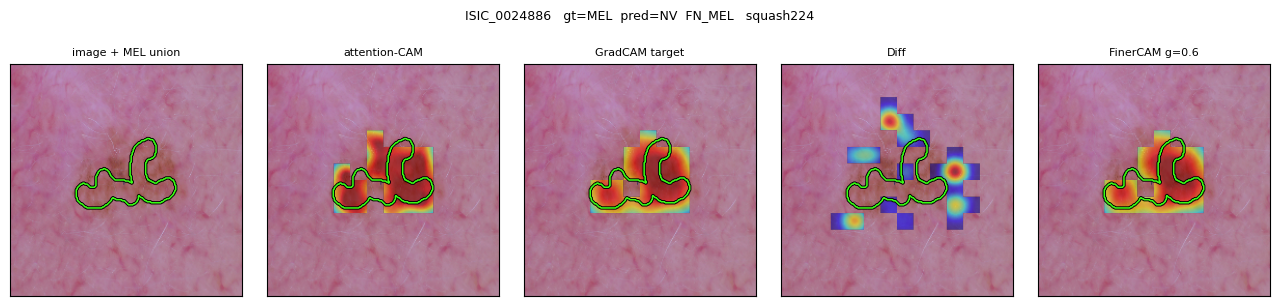

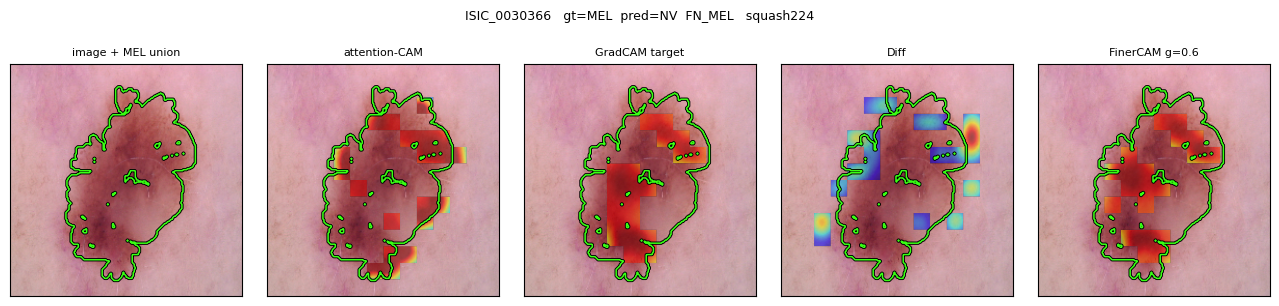

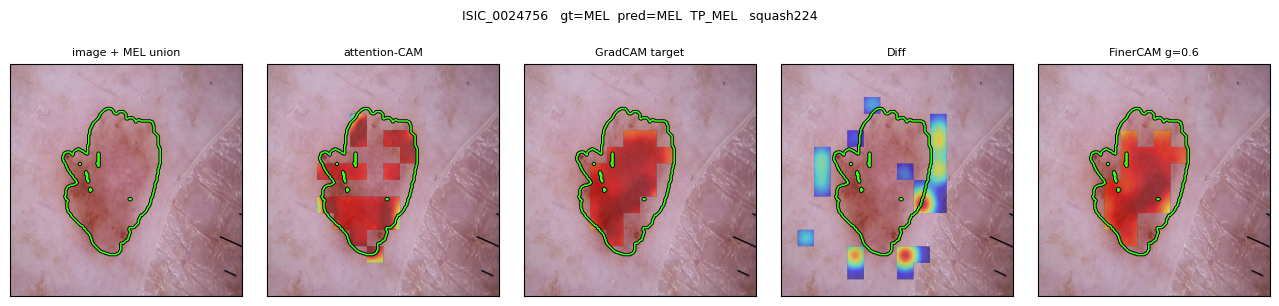

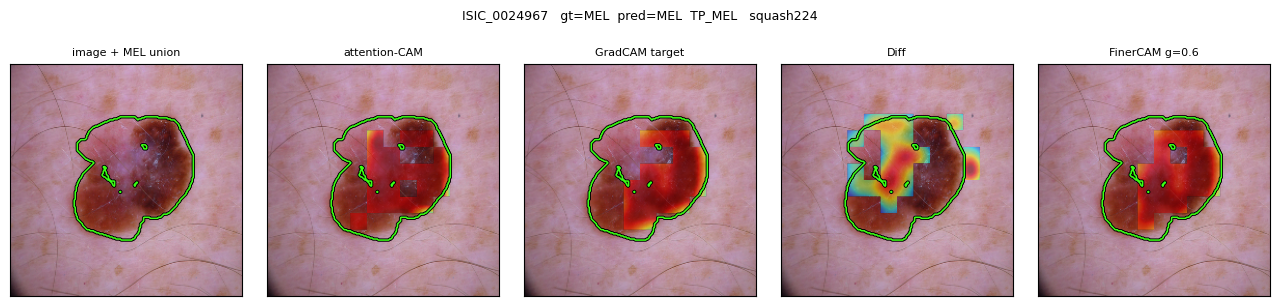

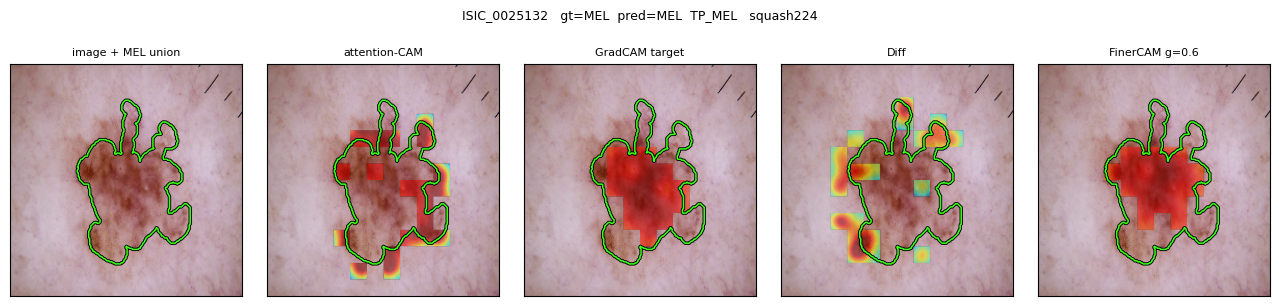

In [9]:
# =============================================================================
# FIGURE. One row per image, rendered in the SAME geometry the model sees.
# Columns: RGB with MEL union outline, attention-CAM, GradCAM, Diff, FinerCAM.
#
# EXPECT heat concentrated on the lesion at alpha=5.
# WATCH  a CAM that looks like uniform noise means the checkpoint or the
#        pooling flag is wrong.
# =============================================================================
qc_pass = qc[qc.qc_pass]


def display_rgb(rel):
    img = np.array(Image.open((HAM_ROOT / str(rel)).resolve()).convert("RGB"))
    return transform_rgb(img, GEOMETRY)


def mel_union(image_id):
    sub = qc_pass[(qc_pass.Image_ID == image_id) &
                  (qc_pass.label_group == "MEL")]
    if not len(sub):
        return None
    acc = None
    for _, r in sub.iterrows():
        m = np.array(Image.open(r.mask_path).convert("L")) > 127
        acc = m if acc is None else (acc | m)
    return transform_mask(acc, GEOMETRY)[0]


def show(image_id):
    r = eval_df[eval_df.image_id == image_id].iloc[0]
    rgb = display_rgb(r.image_rel_path)
    un = mel_union(image_id)
    raw = act_dirs[("ha5", 0.6)] / "raw_cams"

    panels = [
        (None, "image + MEL union"),
        (np.load(attn_dirs["ha5"] / f"{image_id}_attncam_a.npy"), "attention-CAM"),
        (cam_to_grid(np.load(raw / f"{image_id}_gradcam_a.npy")), "GradCAM target"),
        (cam_to_grid(np.load(raw / f"{image_id}_map_diff.npy")), "Diff"),
        (cam_to_grid(np.load(raw / f"{image_id}_finercam.npy")), "FinerCAM g=0.6"),
    ]

    fig, axes = plt.subplots(1, 5, figsize=(13, 2.9))
    for ax, (c, t) in zip(axes, panels):
        ax.imshow(rgb)
        if c is not None:
            sel = topk_fixed(c)
            cn = norm01(c)
            up_sel = cv2.resize(sel.astype(np.float32),
                                (CROP_SIZE, CROP_SIZE),
                                interpolation=cv2.INTER_NEAREST)
            up_cam = cv2.resize(cn, (CROP_SIZE, CROP_SIZE),
                                interpolation=cv2.INTER_CUBIC)
            ax.imshow(np.where(up_sel > 0.5, up_cam, np.nan),
                      cmap="jet", alpha=0.55, vmin=0, vmax=1)
        if un is not None:
            ax.contour(un.astype(float), [0.5], colors="black", linewidths=2.4)
            ax.contour(un.astype(float), [0.5], colors="#39FF14", linewidths=1.1)
        ax.set_title(t, fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])

    p = pred[pred.image_id == image_id].iloc[0]
    fig.suptitle(f"{image_id}   gt={p.gt_label}  pred={p.pred}  "
                 f"{p.case_type}   {GEOMETRY}", fontsize=9, y=1.04)
    plt.tight_layout()
    plt.show()


shown = []
for iid in (list(pred.sort_values("confidence").image_id.head(2)) +
            list(pred[pred.case_type == "TP_MEL"].image_id.head(3))):
    if iid not in shown:
        shown.append(iid)
        show(iid)

In [10]:
rows = []
for (k, g), d in act_dirs.items():
    for f in sorted((d / "raw_cams").glob("*.npy")):
        parts = f.stem.split("_")
        iid = "_".join(parts[:2])
        rows.append({"image_id": iid, "family": "activation",
                     "ckpt": k, "gamma": g,
                     "cam_type": f.stem.replace(iid + "_", ""),
                     "path": str(f.relative_to(REPO))})

for k, d in attn_dirs.items():
    for f in sorted(d.glob("*.npy")):
        parts = f.stem.split("_")
        iid = "_".join(parts[:2])
        rows.append({"image_id": iid, "family": "attention",
                     "ckpt": k, "gamma": np.nan,
                     "cam_type": f.stem.replace(iid + "_", ""),
                     "path": str(f.relative_to(REPO))})

man = pd.DataFrame(rows)
man["geometry"] = GEOMETRY
man.to_csv(EVAL_ROOT / "cam_manifest.csv", index=False)

print(f"total CAM arrays: {len(man)}")
print()
print(pd.crosstab([man.family, man.ckpt, man.gamma], man.cam_type).to_string())
print(f"\nimages covered: {man.image_id.nunique()}  expected {len(eval_df)}")

total CAM arrays: 850

cam_type               finercam  gradcam_a  gradcam_b  map_diff
family     ckpt gamma                                          
activation ha0  0.6          34         34         34        34
           ha3  0.6          34         34         34        34
           ha5  0.6          34         34         34        34
                0.8          34         34         34        34

images covered: 34  expected 34


In [11]:
# =============================================================================
# What predicts agreement between the two CAM formulations.
#
# EXPECT: if agreement tracks confidence or lesion size, it is a property
#         of easy cases. If it tracks nothing, the two formulations simply
#         diverge and both must be reported.
# =============================================================================
d = agree.merge(pred[["image_id", "gt_label", "case_type",
                      "confidence", "correct"]], on="image_id")

les = {}
for _, r in eval_df.iterrows():
    m = np.array(Image.open((HAM_ROOT / str(r.mask_rel_path)).resolve())
                 .convert("L")) > 127
    g = mask_to_cam_grid_geom(m, GEOMETRY)
    les[r.image_id] = float((g >= 0.5).mean())
d["lesion_area"] = d.image_id.map(les)

print("agreement by case type:")
print(d.groupby("case_type")[["topk_iou", "spearman"]]
      .agg(["count", "median"]).round(3).to_string())
print()
print("correlation of topk_iou with:")
for c in ["confidence", "lesion_area", "attn_nonzero", "act_nonzero"]:
    print(f"  {c:<14} {d.topk_iou.corr(d[c], method='spearman'):+.3f}")

print("\nlowest agreement:")
print(d.nsmallest(5, "topk_iou")[["image_id", "gt_label", "case_type",
                                  "confidence", "topk_iou"]].round(3).to_string(index=False))
print("\nhighest agreement:")
print(d.nlargest(5, "topk_iou")[["image_id", "gt_label", "case_type",
                                 "confidence", "topk_iou"]].round(3).to_string(index=False))

agreement by case type:
          topk_iou        spearman       
             count median    count median
case_type                                
FN_MEL           4  0.779        4  0.758
FP_MEL          10  0.538       10  0.861
TN_NV            8  0.270        8  0.862
TP_MEL          12  0.356       12  0.857

correlation of topk_iou with:
  confidence     -0.035
  lesion_area    -0.704
  attn_nonzero   -0.646
  act_nonzero    -0.530

lowest agreement:
    image_id gt_label case_type  confidence  topk_iou
ISIC_0025132      MEL    TP_MEL       0.926     0.111
ISIC_0030798      MEL    TP_MEL       0.887     0.111
ISIC_0030225       NV    FP_MEL       0.885     0.143
ISIC_0031408      MEL    TP_MEL       0.864     0.143
ISIC_0027420      MEL    TP_MEL       0.896     0.176

highest agreement:
    image_id gt_label case_type  confidence  topk_iou
ISIC_0029013      MEL    FN_MEL       0.812     0.905
ISIC_0033556       NV    FP_MEL       0.889     0.905
ISIC_0024886      MEL    FN_ME

In [13]:
# =============================================================================
# NEGATIVE CONTROL, in distribution.
#
# Gaussian noise is far outside the training distribution for a dermoscopy
# model, so it probes the patch embedding rather than any learned prior.
#
# Two better controls.
#   grey       uniform field at dataset mean colour. no structure at all.
#   scrambled  phase randomised real image. keeps colour and power spectrum,
#              destroys all spatial structure.
#
# EXPECT rho near 0 under both if there is no positional prior.
# READ   a consistent negative sign across controls and poolings would
#        indicate a real centre prior. Anything else is noise.
# =============================================================================
model = load_model("ha5")

c0 = (CAM_GRID - 1) / 2
ys_g, xs_g = np.mgrid[0:CAM_GRID, 0:CAM_GRID]
DIST = np.hypot(ys_g - c0, xs_g - c0) / np.hypot(c0, c0)

MEAN = np.array([0.485, 0.456, 0.406], np.float32)
STD  = np.array([0.229, 0.224, 0.225], np.float32)


def to_tensor(arr01):
    x = torch.from_numpy(((arr01 - MEAN) / STD).transpose(2, 0, 1))
    return x.unsqueeze(0).float().to(DEVICE)


def phase_scramble(img01, rng):
    out = np.empty_like(img01)
    for c in range(3):
        F = np.fft.fft2(img01[..., c])
        ph = np.angle(np.fft.fft2(rng.standard_normal(img01.shape[:2])))
        out[..., c] = np.real(np.fft.ifft2(np.abs(F) * np.exp(1j * ph)))
    return np.clip(out, 0, 1)


rng = np.random.default_rng(0)
gen = torch.Generator(device="cpu").manual_seed(0)
banks = {"gaussian": [], "grey": [], "scrambled": []}

for i, (_, r) in enumerate(eval_df.head(12).iterrows()):
    img = np.asarray(Image.open((HAM_ROOT / str(r.image_rel_path)).resolve())
                     .convert("RGB").resize((CROP_SIZE, CROP_SIZE))) / 255.0
    img = img.astype(np.float32)

    banks["gaussian"].append(
        (torch.randn(1, 3, CROP_SIZE, CROP_SIZE, generator=gen) * 0.5).to(DEVICE))
    banks["grey"].append(
        to_tensor(np.full_like(img, img.mean(axis=(0, 1)))))
    banks["scrambled"].append(to_tensor(phase_scramble(img, rng)))

print(f"{'control':<12} {'rho':>8} {'p':>8} {'centre':>8} {'ring':>8}")
print("-" * 48)
ctrl_rows = []
for name, xs in banks.items():
    maps = [attention_cam(model, x, MEL_IDX)[0] for x in xs]
    mm = np.mean(maps, axis=0)
    rr = spearmanr(DIST.ravel(), mm.ravel())
    ring = np.r_[mm[0], mm[-1], mm[:, 0], mm[:, -1]].mean()
    print(f"{name:<12} {rr.statistic:+8.3f} {rr.pvalue:8.4f} "
          f"{mm[4:10, 4:10].mean():8.3f} {ring:8.3f}")
    ctrl_rows.append({"pooling": POOL_TAG, "control": name,
                      "rho": rr.statistic, "p": rr.pvalue,
                      "centre": float(mm[4:10, 4:10].mean()),
                      "ring": float(ring)})
    np.save(EVAL_ROOT / f"control_{name}.npy", mm)

pd.DataFrame(ctrl_rows).to_csv(EVAL_ROOT / "positional_controls.csv", index=False)
print("\nInterpretation.")
print("  grey       flat. no preference on featureless input.")
print("  scrambled  strong centre preference on realistic texture with no")
print("             structure. This is a LEARNED positional prior, most")
print("             likely from lesions being photographed centred.")
print("  gaussian   out of distribution, inconsistent across poolings, drop.")

control           rho        p   centre     ring
------------------------------------------------
gaussian       +0.487   0.0000    0.055    0.168
grey           +0.031   0.6625    0.288    0.302
scrambled      -0.642   0.0000    0.356    0.135

Interpretation.
  grey       flat. no preference on featureless input.
  scrambled  strong centre preference on realistic texture with no
             structure. This is a LEARNED positional prior, most
             likely from lesions being photographed centred.
  gaussian   out of distribution, inconsistent across poolings, drop.


In [18]:
print(d.groupby("case_type")[["topk_iou", "spearman", "lesion_area"]]
      .agg(["count", "median"]).round(3).to_string())

          topk_iou        spearman        lesion_area       
             count median    count median       count median
case_type                                                   
FN_MEL           4  0.779        4  0.758           4  0.130
FP_MEL          10  0.538       10  0.861          10  0.332
TN_NV            8  0.270        8  0.862           8  0.278
TP_MEL          12  0.356       12  0.857          12  0.240
